Training

In [2]:
import librosa
filename = 'audio_files/A_2.mp3'

#load audio file
y, sr = librosa.load(filename, sr = None)
print(sr)
y.shape


44100


(702720,)

In [27]:
import numpy as np
import math
def amp_to_db(cqt, ref = 1):
    return np.multiply(20, np.log10(cqt/ref))


def extract_features(y, sr):
    '''''''''

    Takes time-series, converts to CQT (frequency time domain). Averages each bin value across the recording(should take short windows)
    
    '''''''''
    
    cqt = librosa.hybrid_cqt(y, sr = sr, n_bins = 84, bins_per_octave= 12, tuning = 0.0)
    cqt = amp_to_db(cqt)
    cqt_mean = np.mean(cqt, axis = 1)
    return cqt, cqt_mean
    


**Synthetic Dataset Generation**

In [15]:
REF_FREQ = 440

def midi_to_Hz(midi_note: int) -> float:
    return REF_FREQ * 2 ** ((midi_note - 69)/12)

def gen_sin_wave(freq: float, time_vec, amp = 1):
    return amp * np.sin(2 * np.pi * freq * time_vec)

def synth_note(midi_note: int, sr: int, duration: float, num_harmonics=3, amp=1, harmonic_variance=0.0):

    if midi_note < 21 or midi_note > 108:
        raise ValueError("MIDI note must be 21-108")
    
    freq = midi_to_Hz(midi_note)
    t_samp = int(sr * duration)
    t = np.linspace(0, duration, t_samp, endpoint=False)
    
    y = gen_sin_wave(freq, t, amp=amp)
    
    for i in range(2, num_harmonics + 2):
        base_harmonic_amp = amp * (1 / i)
        variance_factor = np.random.uniform(1 - harmonic_variance, 1 + harmonic_variance)
        harmonic_amp = base_harmonic_amp * variance_factor
        y += gen_sin_wave(freq * i, t, amp=harmonic_amp)
    
    y = y / (np.max(np.abs(y)) + 1e-8)
    
    fade_duration = min(0.1, duration * 0.2)
    fade_samples = int(fade_duration * sr)
    fade_in_curve = np.linspace(0.0, 1.0, fade_samples)
    fade_out_curve = np.linspace(1.0, 0.0, fade_samples)
    y[:fade_samples] = y[:fade_samples] * fade_in_curve
    y[-fade_samples:] = y[-fade_samples:] * fade_out_curve
    
    return y, freq

#------ synth_note() verification------#

a, freq = synth_note(69, 44100, 5)
a.shape
extract_features(a,44100)

#--------------------------------------#

45
22.332255768748652
(84,)


In [16]:
def add_noise(x, snr = 0):
    if snr == 0:
        return x
    signal_power = np.mean(x ** 2)
    raw_noise = np.random.normal(0,1, x.shape)
    raw_noise_power = np.mean(raw_noise ** 2)

    snr_linear = 10 ** (snr / 10.0)

    scaling_factor = np.sqrt(signal_power / (raw_noise_power * snr_linear))
    scaled_noise = raw_noise * scaling_factor

    noisy_soundwave = x + scaled_noise
    return noisy_soundwave


In [29]:
def generate_dataset(sr=44100, duration=2):
    dataset_x = []
    dataset_y = []
    
    for midi_note in range(21, 109):
        for harm_var in [0.0, 0.05, 0.1, 0.15]:
            x, _ = synth_note(midi_note, sr, duration, num_harmonics=3, harmonic_variance=harm_var)
            for snr in [0, 10, 20, 30]:
                x_new = add_noise(x, snr)
                _, cqt_mean = extract_features(x_new, sr)  
                dataset_x.append(cqt_mean)
                dataset_y.append(midi_note)  # 0–87
    
    X = np.array(dataset_x)  # Shape: (num_samples, 84)
    Y = np.array(dataset_y)
    return X, Y
X, Y = generate_dataset()



KeyboardInterrupt: 

(1408, 84)
(1408,)


In [61]:
#%----- Bin # to Note checker-----

# Verify that peak bin corresponds to A4 (440 Hz)
fmin = librosa.note_to_hz('C1')  # 32.7 Hz #lowest bin frequency
freqs = librosa.cqt_frequencies(n_bins=84, fmin=fmin, bins_per_octave=12)
peak_bin = 45 # CHANGE THIS VALUE FOR CHECKER
peak_freq = freqs[peak_bin]
a4_freq = librosa.note_to_hz('A4')  # 440 Hz

print(f"Peak bin: {peak_bin}")
print(f"Peak frequency: {peak_freq:.2f} Hz")
print(f"A4 frequency: {a4_freq:.2f} Hz")
print(f"Difference: {abs(peak_freq - a4_freq):.2f} Hz")
print(f"✓ Phase 1 verified: Peak bin corresponds to A4" if abs(peak_freq - a4_freq) < 5 else "✗ Peak bin does NOT match A4")



Peak bin: 45
Peak frequency: 440.00 Hz
A4 frequency: 440.00 Hz
Difference: 0.00 Hz
✓ Phase 1 verified: Peak bin corresponds to A4


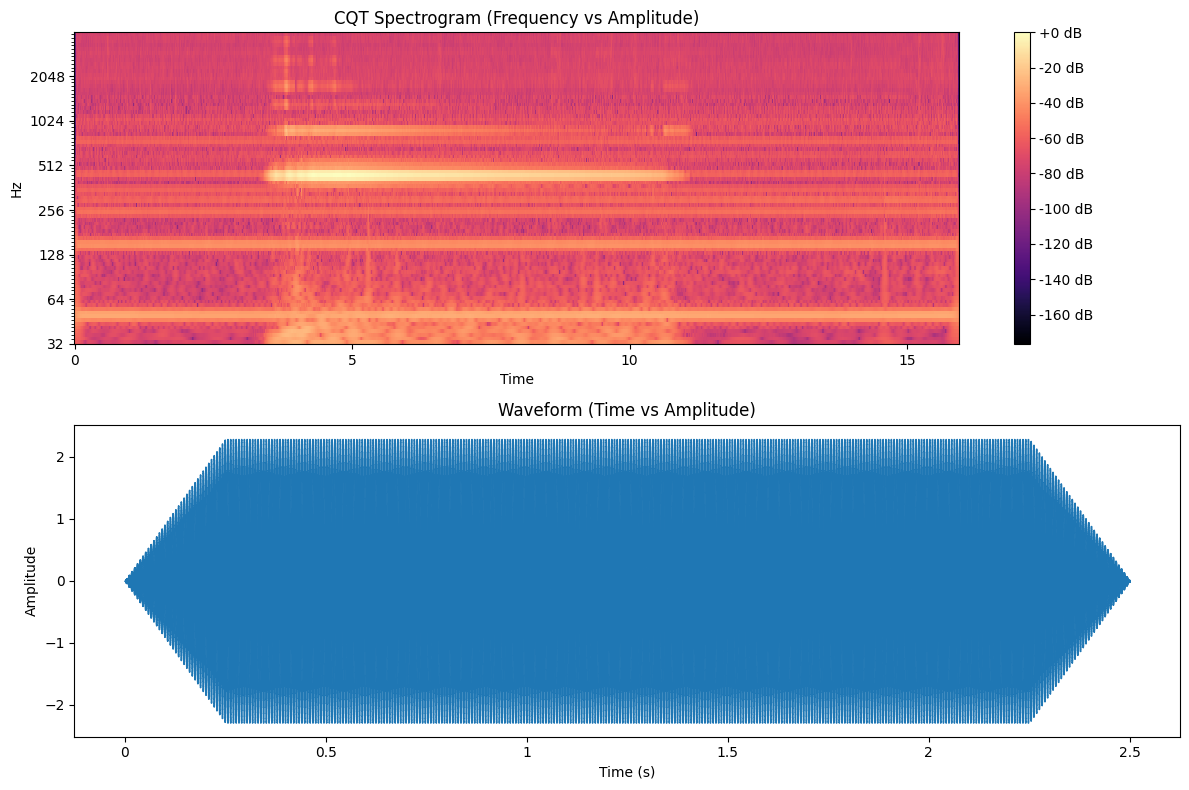

(84, 1373)

In [ ]:
#%----General Plotting-----$#
import librosa.display
import matplotlib.pyplot as plt

# Create subplots: CQT (freq vs amp) and waveform (time vs amp)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot CQT spectrogram (frequency vs amplitude)
img = librosa.display.specshow(amp_to_db(cqt, ref=np.max(cqt)), sr=sr, x_axis='time', y_axis='cqt_hz', ax=ax1)
ax1.set_title('CQT Spectrogram (Frequency vs Amplitude)')
fig.colorbar(img, ax=ax1, format='%+2.0f dB')

# Plot waveform (time vs amplitude)
librosa.display.waveshow(y, sr=sr, ax=ax2)
ax2.set_title('Waveform (Time vs Amplitude)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

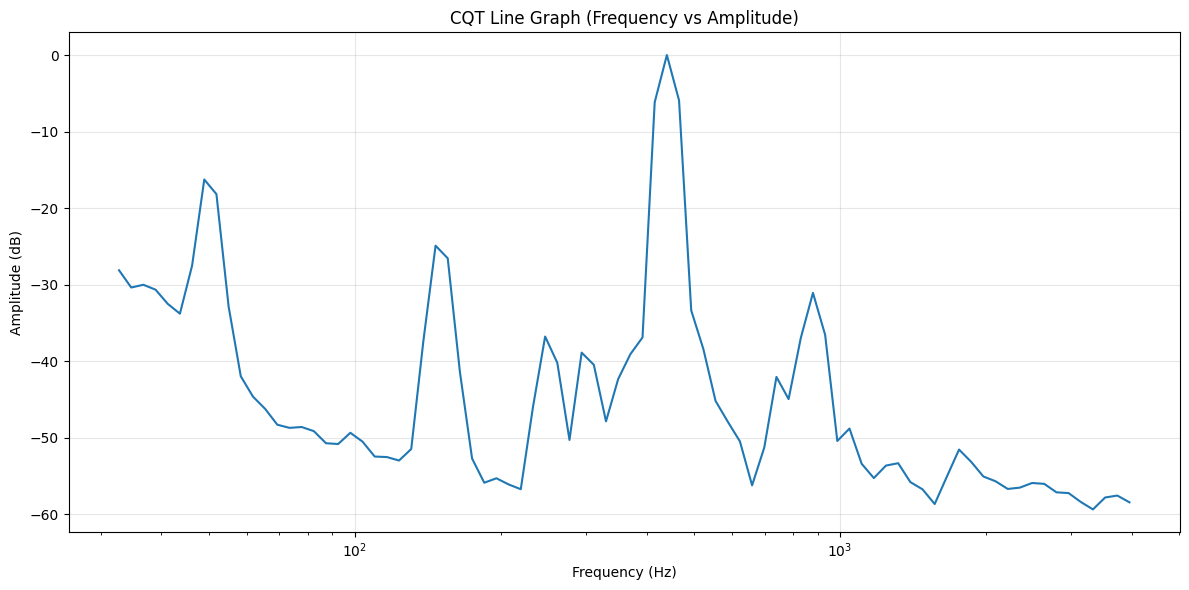

In [27]:
#%----CQT Line Graph
# Plot CQT as line graph (magnitude vs frequency)
fig, ax = plt.subplots(figsize=(12, 6))

# Average CQT magnitude across time to get overall frequency content
cqt_mag = np.abs(cqt)
cqt_mean = np.mean(cqt_mag, axis=1)

# Get frequency values for CQT bins
freqs = librosa.cqt_frequencies(n_bins=cqt.shape[0], fmin=librosa.note_to_hz('C1'), bins_per_octave=12)

# Plot as line graph
ax.plot(freqs, librosa.amplitude_to_db(cqt_mean, ref=np.max(cqt_mean)), linewidth=1.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude (dB)')
ax.set_title('CQT Line Graph (Frequency vs Amplitude)')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()